In [1]:
from IPython.display import Image, display

1. Proxies and reverse proxies are servers that sit between clients and servers to improve **security, privacy and performance**.

2. A Proxy server (sometimes called a Forward proxy) acts on behalf of clients, while a Reverse Proxy acts on behalf of servers.

## 1. What is a Proxy Server?

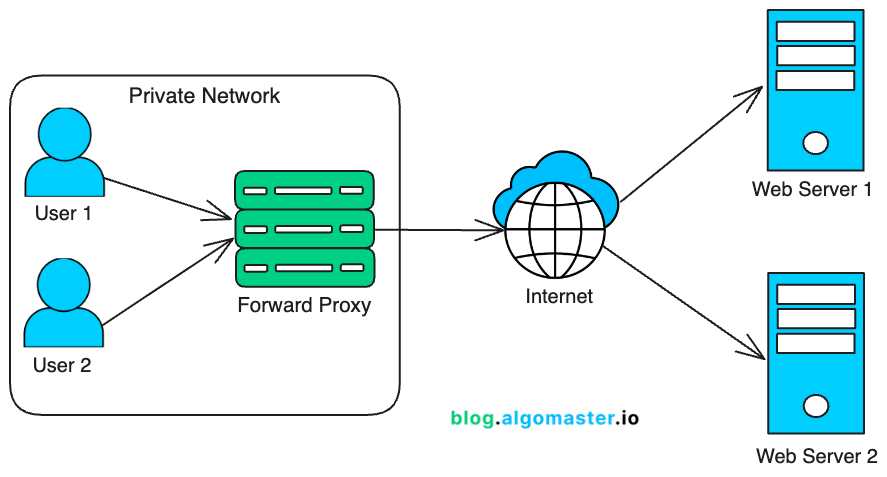

In [2]:
display(Image(filename='Utils/5.png'))

1. A proxy is an entity that has the authority to act on behalf of another.

2. In computer terms, a proxy (or a forward proxy) is a server that acts on behalf of clients on a network.

3. When you send a request, like opening a webpage, the proxy intercepts it, forwards it to the target server, and then relays the server’s response back to you.


Think of **proxy server as a middleman that sits between a private network and the public internet**.

Let’s walk through a simplified example of how a proxy server handles a request:

1. The user types a website URL into their browser. The request is intercepted by the proxy server instead of going directly to the website.

2. The proxy server examines the request to decide if it should forward it, deny it, or serve a cached copy.

3. If the proxy decides to forward the request, it contacts the target website. The website **sees only the proxy server’s IP, not the user’s**.

4. When the target website responds, the proxy receives the response and relays it to the user.


**Key Benefits of Proxy Servers:**

1. **Privacy and Anonymity**: Proxy servers hide your IP address by using their own, so the destination server cannot know your real location or identity.

2. **Access Control**: Organizations use proxies to enforce content restrictions, monitor internet usage.

3. **Security**: Proxies can filter out malicious content and block suspicious sites, providing an additional layer of security.

4. **Improved Performance**: Proxies **cache frequently accessed content, reducing latency** and improving load times for websites.




**QUESTION**

**Is a VPN the same as a Proxy?**

No. While both hide your IP, a VPN **encrypts all your internet traffic, making it more secure**. A proxy only forwards specific requests without necessarily encrypting them.

**Proxy = Mask + No encryption (app-level)**

**VPN = Mask + Encryption (system-level)**

Example : 

**VPN ;**

1. You connect to a VPN in Germany. Then All your traffic (browser, email, Zoom, etc.) goes securely through Germany’s VPN server.

**Proxy :** 

1. Works only for specific apps or protocols, like your browser or an API client.
2. It intercepts and forwards HTTP/HTTPS requests.
3. Usually **doesn’t encrypt the entire internet traffic** ,just the app that’s configured to use it.


**Real-World Applications of Proxy Servers**

**1. Bypassing Geographic Restrictions**

   1. One of the most common uses of proxy servers is bypassing geographic restrictions on websites and content.

   2. Streaming services, for instance, often offer different content based on a user’s location. With a proxy server based in the target region, you can access that region’s content library as if you were a local user.

   3. Example: Suppose you’re in India and want to access the US library of a streaming platform (eg.. Netflix). By **connecting to a proxy server located in the US, your request to the streaming platform will appear to be coming from the US**, allowing access to its content as if you were a US-based viewer.

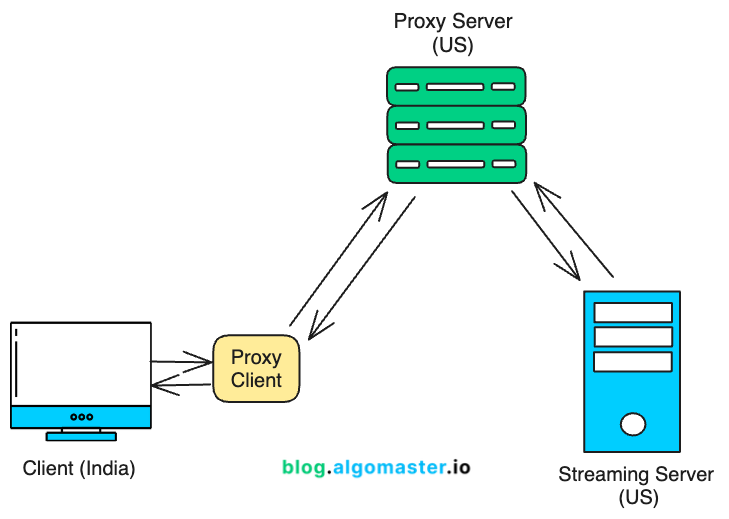

In [4]:
display(Image(filename='Utils/6.png'))


**2. Speed and Performance Optimization (Caching)**

   1. Proxies can store cached versions of frequently accessed content, enabling faster load times and reducing bandwidth usage.
   
   2. When a user requests cached content, the proxy server serves the stored copy rather than fetching it from the destination server, which reduces latency.

   3. To avoid stale content, it uses a **Time-To-Live (TTL) value, automatically expiring cached data after the configured time**.

   4. Example: An organization with hundreds of **employees frequently accessing the same online resources** can deploy a caching proxy. This proxy caches common websites in it’s database, so subsequent requests are served quickly from the **proxy’s storage, saving time and bandwidth**.


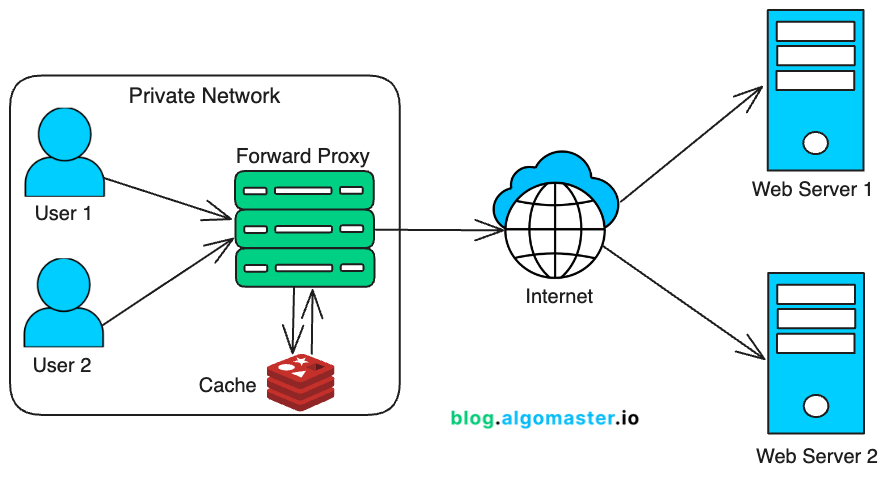

In [5]:
display(Image(filename='Utils/7.png'))

## 2. What is a Reverse Proxy?

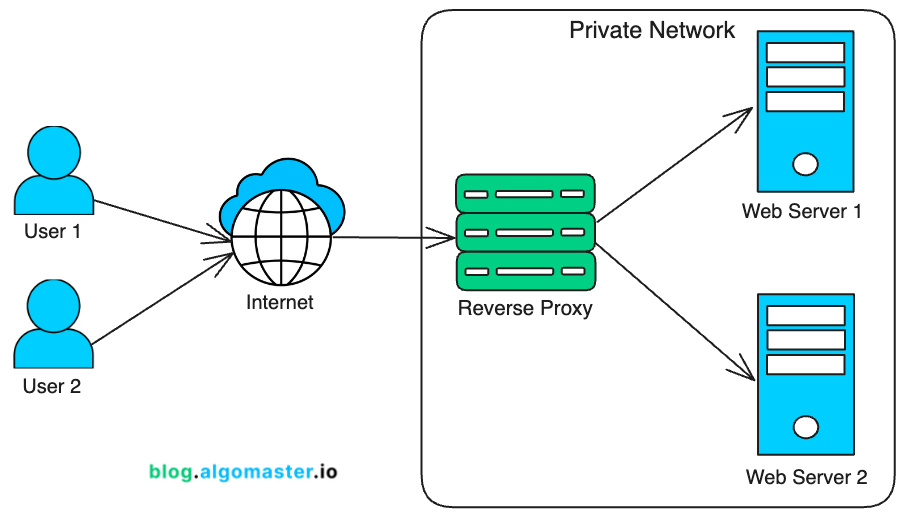

In [6]:
display(Image(filename='Utils/8.png'))

1. A reverse proxy is the reverse of a forward proxy. It **regulates traffic coming** into a network.

2. It sits in front of servers, **intercepts client requests and forwards them to backend servers based on predefined rules.**

3. Think of a reverse proxy as a gatekeeper. Instead of hiding clients from the server, it hides servers from clients.

4. Allowing direct access to **servers can pose security risks, exposing them to threats** like hackers and DDoS attacks.

1. **A reverse proxy mitigates these risks by creating a single, controlled point of entry that filters and regulates incoming traffic all while keeping server IP addresses hidden.**

2. With a reverse proxy in place, c**lients no longer interact directly with the servers**. They only communicate with the reverse proxy.



Let’s walk through a simplified example of how a proxy server handles a request:

1. A user types a website URL into their browser, which sends a request to the server.

2. The reverse proxy server receives the request before it reaches the backend servers.

3. Based on predefined rules (like load balancing or server availability), the reverse proxy forwards the request to the appropriate backend server.

4. The backend server processes the request and sends a response back to the reverse proxy.

5. The reverse proxy relays the response to the client, with the client never directly interacting with the backend servers.

**Key Benefits of Reverse Proxy**

1. **Enhanced Security:** By acting as a protective layer, a reverse proxy hides backend servers from clients, reducing the risk of attacks directly targeting backend infrastructure.

2. **Load Balancing:** A reverse proxy can distribute incoming requests evenly across multiple backend servers, improving system reliability and preventing server overload.

3. **Caching Static Content:** Reverse proxies can cache static assets like images, CSS, and  JavaScript, reducing the need to fetch these files from the backend repeatedly.

4. **SSL Termination:** Reverse proxies can handle SSL encryption, offloading this work from backend servers.

5. **Web Application Firewall (WAF):** Reverse proxies can inspect incoming requests, acting as a firewall to detect and block malicious traffic.

**Real-World Example of a Reverse Proxy**

1. **Cloudflare’s reverse proxy** is widely used by global websites and applications to boost speed, security, and reliability.

2. It’s **Web Application Firewall (WAF) and DDoS protection blocks malicious traffic** before it reaches the site’s servers, safeguarding against attacks and improving uptime.

3. **Cloudflare’s global content caching caches static and dynamic content** at over 200 data centers around the world, storing frequently accessed files (like images, CSS, and JavaScript) closer to users. 

4. This significantly **reduces load times and latency**, as requests don’t always need to travel to the origin server.


**Setting Up a Reverse Proxy with Nginx**

One of the most popular reverse proxy tools is **Nginx**.

Here’s how you can set up a basic **reverse proxy configuration using Nginx on a Linux server**.

1. Install Nginx

    ```
    sudo apt update sudo apt install nginx
    ```

2. Add Reverse Proxy Configuration

    ```
    server {
        listen 80;

        location / {
            proxy_pass http://backend_server_ip;
            proxy_set_header Host $host;
            proxy_set_header X-Real-IP $remote_addr;
            proxy_set_header X-Forwarded-For $proxy_add_x_forwarded_for;
        }
    }
    ```

3. Test and Reload Nginx

    ```
    sudo nginx -t sudo systemctl reload nginx
    Load Balancing Across Multiple Servers
    ```


**Load Balancing Across Multiple Servers**

1. For a high-traffic website, **spreading incoming requests across multiple backend servers** is crucial.

2. A **reverse proxy can implement load balancing algorithms** such as round-robin, least connections, or IP hash, ensuring optimal distribution of traffic.

    ```
    upstream backend_servers {
        ip_hash;
        server backend1.example.com;
        server backend2.example.com;
        server backend3.example.com;
    }
    

    server {
        listen 80;
        server_name example.com;

        location / {
            proxy_pass http://backend_servers;
            proxy_set_header Host $host;
            proxy_set_header X-Real-IP $remote_addr;
            proxy_set_header X-Forwarded-For $proxy_add_x_forwarded_for;
        }
    }

    ```

3. Nginx uses round robin by default. To change it, we can simply add the required algorithm (eg.. ip_hash) in the upstream block.

4. With this configuration, Nginx will balance requests among backend1, backend2, and backend3, ensuring no single server becomes overwhelmed.

## Summary 

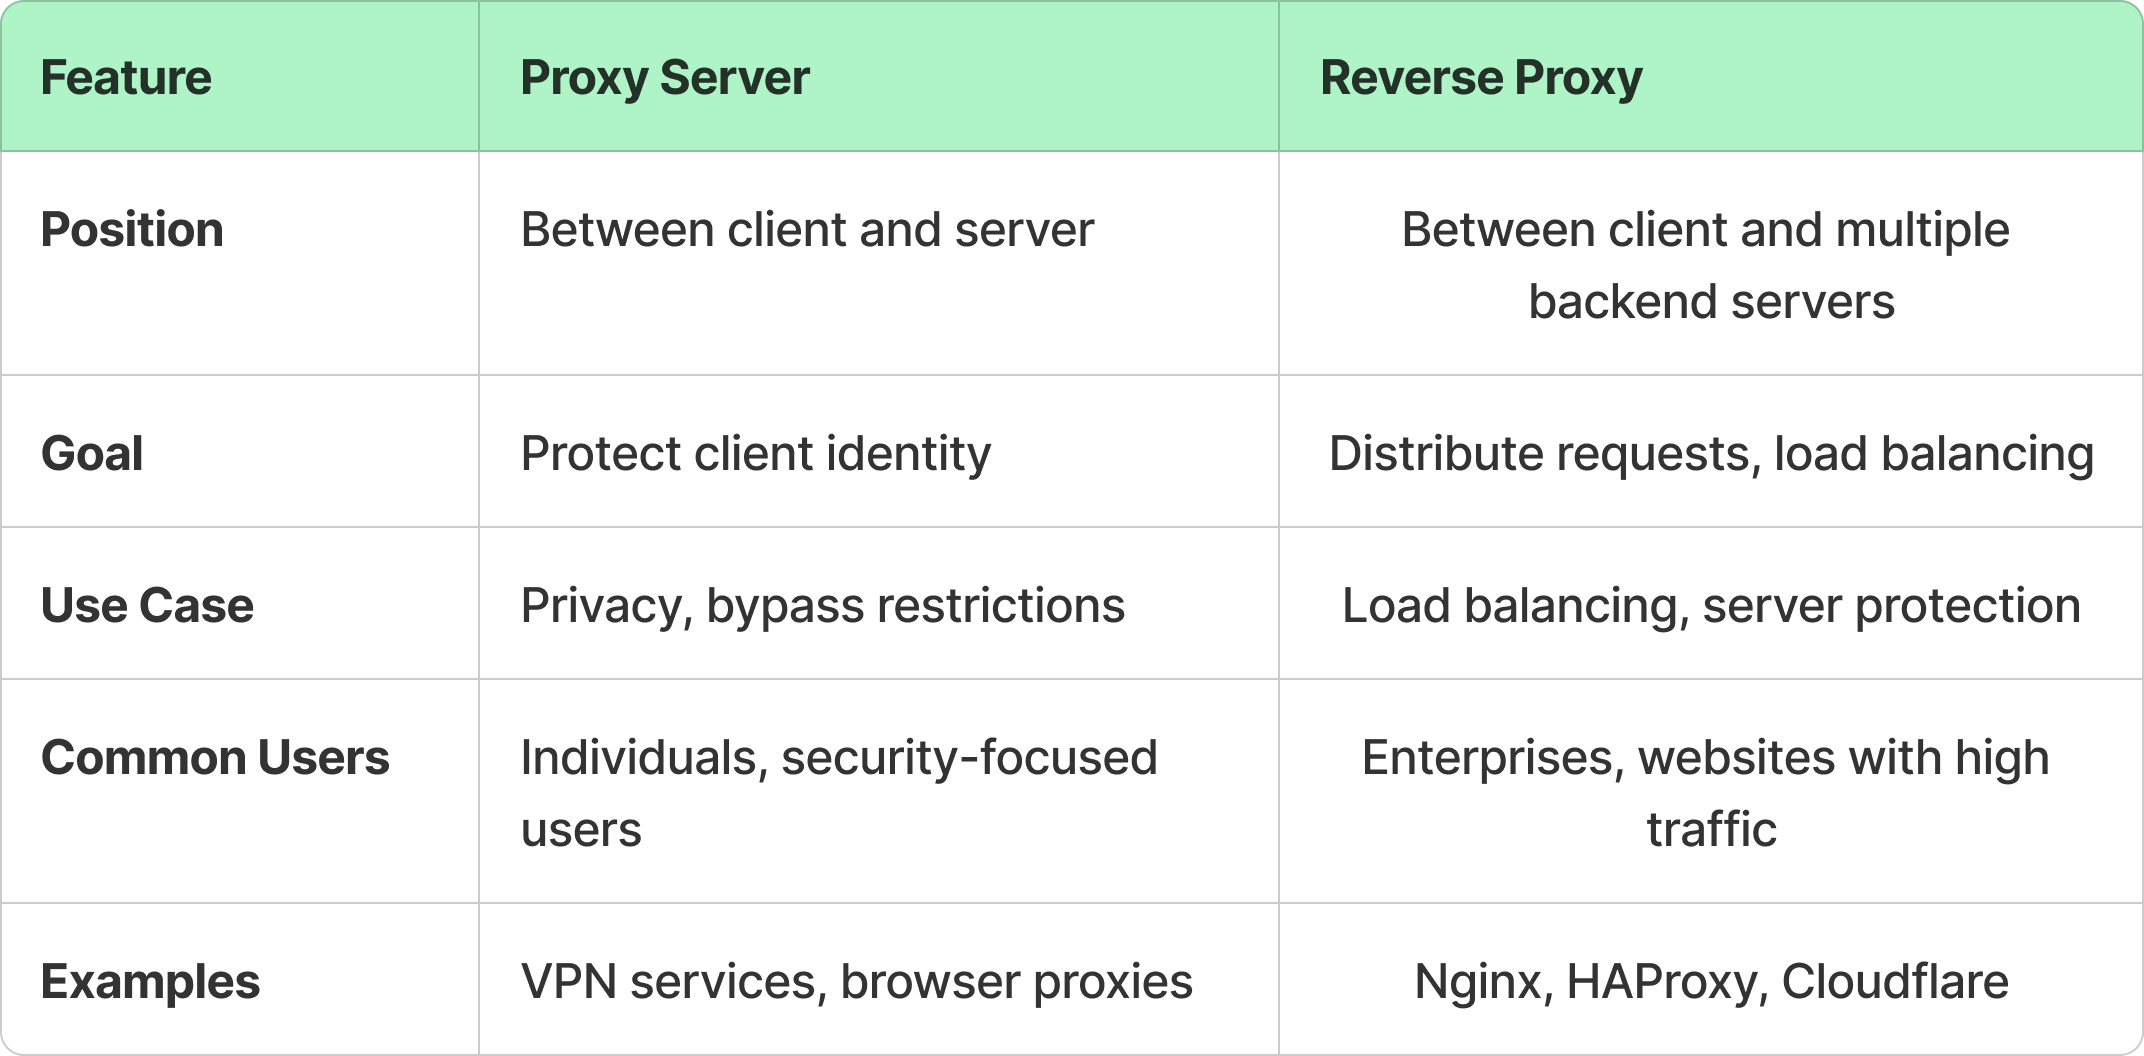

In [7]:
display(Image(filename='Utils/9.png'))